---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Основи радіоелектроніки. Частина 2"</h2></b></p>
<p style="text-align: center;"><b><h3>Тема 10. Перехідні процеси. Класичний метод</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Питання теми:</b></p>
<ul style="text-align: left;">
  <li>Перехідні процеси в лінійних електричних ланцюгах із зосередженими параметрами, основні поняття та визначення</li>
  <li>Перший закон комутації</li>
  <li>Другий закон комутації</li>
  <li>Порядок розрахунку перехідних процесів класичним методом</li>
  <li>Характеристичне рівняння: способи отримання і властивості коренів</li>
  <li>Визначення сталих інтегрування з початкових умов</li>
  <li>Розрахунок перехідного процесу RL ланцюга</li>
  <li>Розрахунок перехідного процесу RC ланцюга</li>
  <li>Вмикання кіл на синусоїдальну напругу</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Тема 10 з 16</p>
</div>
    </th>
  </tr>
</table>

---


---

<p style="text-align: center;"><b>Зміст</b></p>

* [Перехідні процеси в лінійних електричних ланцюгах із зосередженими параметрами, основні поняття та визначення](#commutation-law)
    * [Перший закон комутації](#first-commutation-law)
    * [Другий закон комутації](#second-commutation-law)
    * [Порядок розрахунку перехідних процесів класичним методом](#classical-method-algorithm)
    * [Характеристичне рівняння: способи отримання і властивості коренів](#characteristic-equation)
    * [Визначення сталих інтегрування з початкових умов](#integration-constants)
    * [Розрахунок перехідного процесу RL ланцюга](#RL-commutation-calculation-classic)
    * [Розрахунок перехідного процесу RC ланцюга](#RC-commutation-calculation-classic)
* [Вмикання кіл на синусоїдальну напругу](#ac-switching)
* [📚 Рекомендована література та ресурси](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*.

---

**Підключення бібліотек.** SymPy — символьні обчислення, NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice — моделювання схем, schemdraw — побудова схем. Тут же задано стиль графіків та умовні позначення елементів за ДСТУ. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import sympy as smp
import sympy as sp
from sympy import *
from sympy import symbols, Matrix
from sympy.plotting.plot import MatplotlibBackend, Plot
import matplotlib.pyplot as plt
from matplotlib.widgets import Cursor
import numpy as np
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import math
from engineering_notation import EngNumber

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()
from PySpice.Doc.ExampleTools import find_libraries
from PySpice.Probe.Plot import plot
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник,
    # джерело ЕРС — коло зі стрілкою (напрямок дії ЕРС), джерело струму — коло з подвійною стрілкою
    from schemdraw.segments import Segment
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

---

## Перехідні процеси в лінійних електричних ланцюгах із зосередженими параметрами, основні поняття та визначення <a class="anchor" id="commutation-law"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати фізичну суть перехідних процесів та причини їх виникнення
> - Формулювати перший та другий закони комутації
> - Визначати початкові умови за законами комутації
> - Розраховувати перехідні процеси в RL та RC ланцюгах класичним методом
> - Знаходити постійну часу та будувати часові діаграми

</div>

### 📖 Ключові поняття

| Поняття | Визначення |
|---------|-----------|
| **Перехідний процес** | Зміна струмів/напруг при переході між усталеними режимами |
| **Комутація** | Зміна параметрів або топології кола (перемикання ключів) |
| **Постійна часу $\tau$** | Час, за який перехідна складова зменшується в $e$ разів |
| **Усталений режим** | Режим, при якому всі змінні не залежать від часу (або змінюються за законом джерела) |
| **Початкові умови** | Значення струмів та напруг безпосередньо після комутації $t(0_+)$ |



**Перехідним** називається процес зміни в часі струмів та напруг, який виникає в електричній схемі при переході від одного усталеного режиму до іншого внаслідок комутації.

**Комутація** – це зміна параметрів елементів (наприклад, зміна величини опору резистора) або зміна топології кола, яку на електричній схемі відображають за допомогою ідеальних ключів.

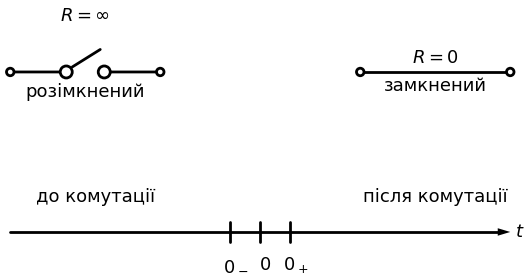

In [2]:
# Схема: ідеальний ключ у розімкненому та замкненому стані; моменти часу до і після комутації
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=13, unit=3) as d:
        d.add(elm.Dot(open=True).at((0, 0)))
        d.add(elm.Switch().right().label('$R = \\infty$', ofst=0.5).label('розімкнений', loc='bottom'))
        d.add(elm.Dot(open=True))
        d.add(elm.Dot(open=True).at((7, 0)))
        d.add(elm.Line().right(3).label('$R = 0$').label('замкнений', loc='bottom'))
        d.add(elm.Dot(open=True))
        d.add(elm.Arrow().at((0, -3.2)).right(10).label('$t$', loc='right'))
        for x, name in [(4.4, '$0_-$'), (5, '$0$'), (5.6, '$0_+$')]:
            d.add(elm.Line().at((x, -3.0)).down(0.4))
            d.add(elm.Label().at((x, -3.75)).label(name))
        d.add(elm.Label().at((1.6, -2.4)).label('до комутації'))
        d.add(elm.Label().at((8.4, -2.4)).label('після комутації'))

**Ідеальні ключі** мають такі властивості:
1. в замкненому стані опір ключа дорівнює нулю;
1. в розімкненому стані провідність ключа дорівнює нулю;
1. час перемикання ключа дорівнює нулю

Необхідними умовами **виникнення перехідних процесів** є:
- наявність у колі хоча б одного реактивного елемента, оскільки саме в часовому процесі переходу від одного усталеного режиму до іншого змінюється накопичена в цьому елементі електромагнітна енергія;
- наявність саме такої комутації, при якій замикаючий ключ знаходиться під ненульовою напругою, або розмикаючий ключ проводить ненульовій струм, оскільки за протилежних умов комутація не змінює стану електричного кола.

---

### Перший закон комутації <a class="anchor" id="first-commutation-law"></a>

Розглянемо схему з індуктивністю **L** і резистором **R**:

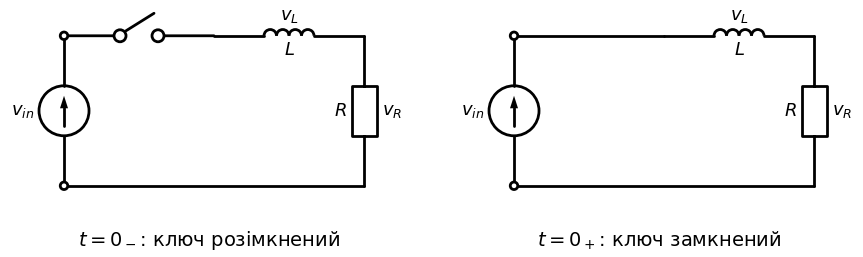

In [3]:
# Схема: RL-коло до і після комутації
if SCHEMDRAW_AVAILABLE:
    def switching_pair(element, name, value_label):
        """Коло до комутації (ключ розімкнений, t = 0−) і після неї (ключ замкнений, t = 0+)."""
        with schemdraw.Drawing(fontsize=13, unit=3) as d:
            for x0, closed, caption in [(0, False, '$t = 0_-$: ключ розімкнений'), (9, True, '$t = 0_+$: ключ замкнений')]:
                src = d.add(EMF().at((x0, 0)).up().label('$v_{in}$'))
                d.add(elm.Dot(open=True).at(src.end))
                if closed:
                    d.add(elm.Line().at(src.end).right(3))
                else:
                    d.add(elm.Switch().at(src.end).right())
                d.add(element().right().label(name).label(value_label, loc='bottom'))
                d.add(elm.Resistor().down().label('$R$', loc='top').label('$v_R$', loc='bottom'))
                d.add(elm.Line().left().tox(src.start))
                d.add(elm.Dot(open=True).at(src.start))
                d.add(elm.Label().at((x0 + 3, -1.0)).label(caption, fontsize=14))

    switching_pair(elm.Inductor, '$v_L$', '$L$')

Запишемо рівняння яке описує схему:

$$
  v_{in} = v_{R} + v_{L}
$$

Враховуючи що:

$$
v_{R} = i R; \quad   v_{L} = L \frac{di}{dt};
$$

$$
  v_{in} = i R + L \frac{di}{dt}
$$

Якщо би струм міг змінюватись миттєво то похідна струму $i$ буде наближатись до $\infty$:

$$
  \frac{di}{dt} => \infty 
$$ 
  
І відповідно:

$$
  v_{L} = L \frac{di}{dt} => \infty
$$

> У початковий момент після комутації струм в котушці індуктивності залишається саме таким, яким він був безпосередньо перед комутацією

$$
  i_{L}(0_{-}) = i_{L}(0_{+})
$$

---

### Другий закон комутації  <a class="anchor" id="second-commutation-law"></a>
    
Розглянемо схему з ємністю **C** і резистором **R**:

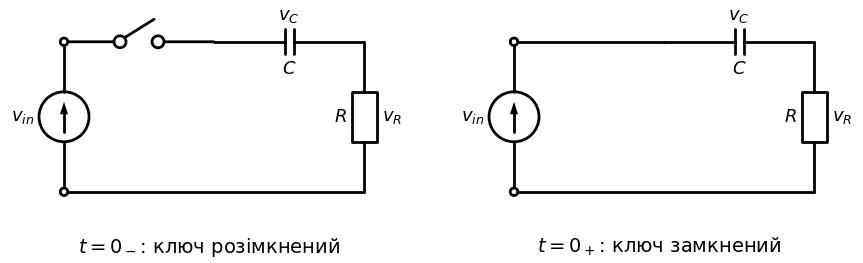

In [4]:
# Схема: RC-коло до і після комутації (функцію switching_pair визначено вище, у розділі про перший закон комутації)
if SCHEMDRAW_AVAILABLE:
    switching_pair(elm.Capacitor, '$v_C$', '$C$')

Запишемо рівняння яке описує схему:

$$
  v_{in} = v_{R} + v_{С};
$$

Враховуючи що:

$$
i_{C} = C \frac{d v_{C}}{dt};
$$

$$
  v_{in} = v_{c} + R C \frac{d v_{C}}{dt};
$$

Якщо би напруга могла змінюватись миттєво:

$$
  \frac{d v_{C}}{dt} => \infty 
$$ 
  
І відповідно:

$$
  i_{C} = C \frac{d v_{C}}{dt} => \infty
$$

> у початковий момент після комутації напруга на конденсаторі залишається саме такою, якою вона була безпосередньо перед комутацією

$$
  v_{C}(0_{-}) = v_{C}(0_{+})
$$

---

### Порядок розрахунку перехідних процесів класичним методом <a class="anchor" id="classical-method-algorithm"></a>

Розрахунок перехідного процесу класичним методом виконують у такій послідовності:

1. **Визначають незалежні початкові умови** — значення $i_L(0_-)$ і $u_C(0_-)$ у колі **до** комутації (в усталеному режимі), і за законами комутації переносять їх на момент одразу після комутації: $i_L(0_+)=i_L(0_-)$, $u_C(0_+)=u_C(0_-)$.
2. **Складають диференціальне рівняння кола після комутації** відносно шуканої величини (струму чи напруги), використовуючи закони Кірхгофа та рівняння елементів.
3. **Знаходять вимушену (усталену) складову** $x_{вим}(t)$ — розв'язок для нового усталеного режиму (значення джерела після комутації: стала напруга, синусоїда тощо).
4. **Складають характеристичне рівняння** однорідного диференціального рівняння і знаходять його корені $p_k$ — вони визначають вигляд вільної складової $x_{вл}(t)$.
5. **Записують загальний розв'язок** $x(t)=x_{вим}(t)+x_{вл}(t)$ з невідомими сталими інтегрування, і, підставивши початкові умови (за потреби — і їх похідні в момент $t=0_+$), знаходять ці сталі.
6. **Записують кінцевий вираз** $x(t)$ і за потреби будують часову діаграму.

### Характеристичне рівняння: способи отримання і властивості коренів <a class="anchor" id="characteristic-equation"></a>

**Спосіб 1 — з диференціального рівняння.** В однорідному диференціальному рівнянні (вимушену складову й джерело прирівнюють до нуля) замінюють похідні $k$-го порядку на $p^k$:

$$\dfrac{d^k x}{dt^k} \;\longrightarrow\; p^k$$

**Спосіб 2 — з операторного (комплексного) опору кола.** Записують повний опір кола відносно розриву (наприклад, для RC — $Z(p)=R+\dfrac{1}{pC}$, як у прикладі вище) і прирівнюють його до нуля: $Z(p)=0$. Обидва способи дають однакове рівняння — це той самий поліном, корені якого визначають динаміку вільного процесу, лише отриманий різними шляхами.

> **Порядок характеристичного рівняння дорівнює порядку кола** — кількості незалежних накопичувачів енергії (котушок і конденсаторів) після їх можливого об'єднання (послідовно/паралельно з'єднані однотипні елементи рахують за один).

**Властивості коренів і відповідний вигляд вільної складової:**

| Тип кореня $p_k$ | Вигляд доданка вільної складової |
|-------------------|-----------------------------------|
| Простий дійсний від'ємний корінь $p_k=-a$ | $A\,e^{-at}$ — аперіодичний (монотонний) спад |
| Кратний дійсний корінь кратності $r$ | $(A_0+A_1t+\dots+A_{r-1}t^{r-1})\,e^{p_k t}$ |
| Пара комплексно-спряжених коренів $p_{1,2}=-\sigma\pm j\omega$ | $e^{-\sigma t}(A\cos\omega t+B\sin\omega t)$ — згасаючі коливання |

Для будь-якого **стійкого** (пасивного, без активних елементів, здатних вносити «негативний опір») електричного кола всі корені характеристичного рівняння мають **від'ємну дійсну частину** ($\operatorname{Re}p_k<0$), тому вільна складова із часом згасає до нуля — саме це й означає завершення перехідного процесу.

### Визначення сталих інтегрування з початкових умов <a class="anchor" id="integration-constants"></a>

Кількість невідомих сталих $A_k$ у вільній складовій **дорівнює порядку кола** (порядку характеристичного рівняння), тому для їх знаходження потрібно стільки ж рівнянь:

- Для кола **першого порядку** досить однієї незалежної початкової умови — $i_L(0_+)$ або $u_C(0_+)$ (див. приклади RL та RC вище).
- Для кола **другого порядку** (RLC, розглянуте нижче) потрібні **дві** умови: сама незалежна початкова умова $x(0_+)$ **і** її похідна $\left.\dfrac{dx}{dt}\right|_{t=0_+}$. Похідну знаходять не з закону комутації напряму (він дає лише саму величину), а складанням рівняння кола (за законом Кірхгофа) в момент $t=0_+$ — наприклад, зі струму конденсатора $i_C(0_+)=C\!\left.\dfrac{du_C}{dt}\right|_{0_+}$, де $i_C(0_+)$ знаходять із першого закону Кірхгофа в цей момент.


---
### Розрахунок перехідного процесу RL ланцюга  <a class="anchor" id="RL-commutation-calculation-classic"></a>

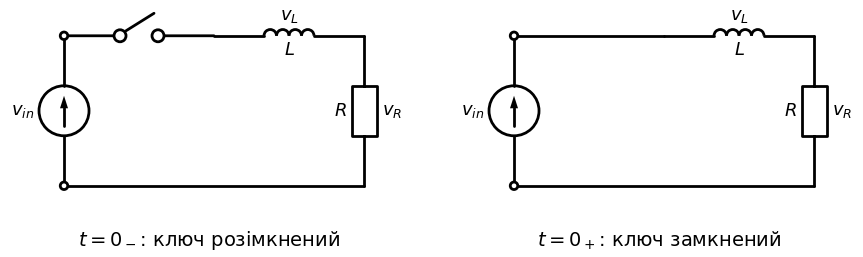

In [5]:
# Схема: RL-коло до і після комутації (функцію switching_pair визначено вище)
if SCHEMDRAW_AVAILABLE:
    switching_pair(elm.Inductor, '$v_L$', '$L$')

Запишемо рівняння яке описує схему:

$$
  v_{in} = i R + L \frac{di}{dt}
$$

**Порядком електричного кола** називають порядок диференційного рівняння, яким описується коло після комутації. Зазвичай порядок кола співпадає з кількістю його реактивних елементів, тобто у даному випадку розраховується перехідний процес в колі
першого порядку з конденсатором. Підставивши значення сталої часу, отримаємо шукане диференційне рівняння:

Розв’язок диференційного рівняння складає вільну та вимушену складові і отримуємо

$$
i(t) = i_{вм} + i_{вл}
$$

Де:

$i_{вм}$ - вимушена складова, тобто усталена реакція кола на дію джерела;

$i_{вл}$ - вільна складова, яка описує перехідний процесс;

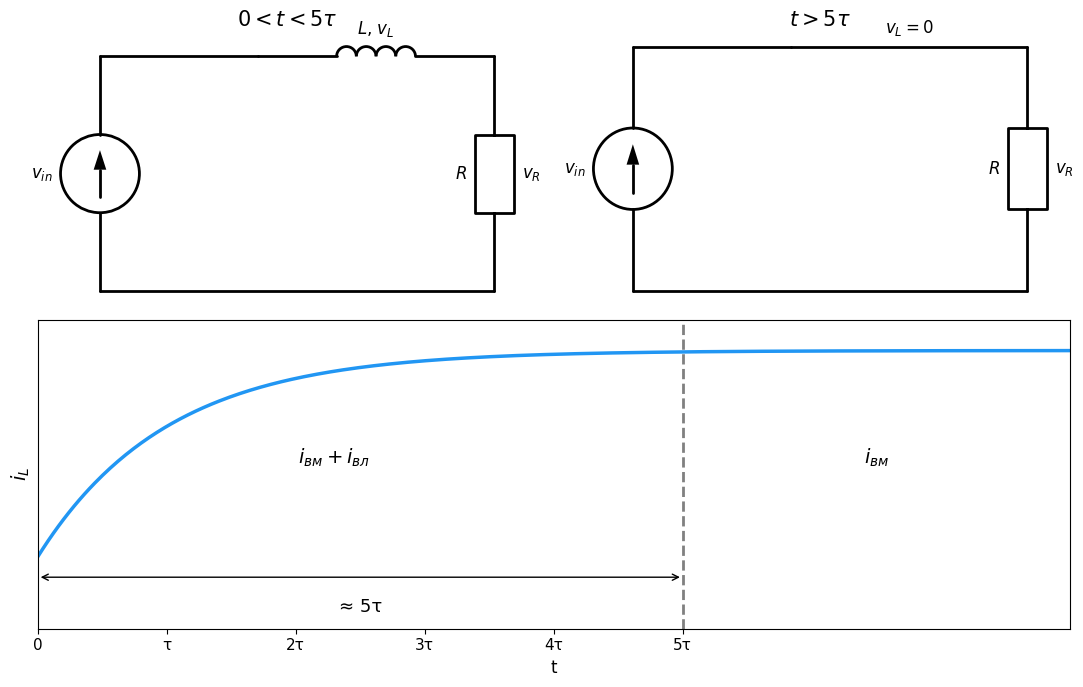

In [6]:
# Схема і графік: струм RL-кола у перехідному та усталеному режимах
if SCHEMDRAW_AVAILABLE:
    def transient_phases(element, top_label, steady_top, curve_label, free_label, steady_label, rc):
        """Перехідний (0 < t < 5τ) і усталений (t > 5τ) режими та графік перехідного процесу."""
        fig = plt.figure(figsize=(11, 7))
        gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.15])
        for k, (title, steady) in enumerate([('$0 < t < 5\\tau$', False), ('$t > 5\\tau$', True)]):
            ax = fig.add_subplot(gs[0, k]); ax.axis('off')
            with schemdraw.Drawing(canvas=ax, fontsize=12, unit=3) as d:
                src = d.add(EMF().up().label('$v_{in}$'))
                d.add(elm.Line().right(2))
                if steady and not rc:
                    d.add(elm.Line().right(3).label(steady_top))          # котушка при постійному струмі — провідник
                else:
                    d.add(element().right().label(steady_top if steady else top_label))
                d.add(elm.Resistor().down().label('$R$', loc='top')
                      .label('$v_R = 0$' if (steady and rc) else '$v_R$', loc='bottom'))
                d.add(elm.Line().left().tox(src.start))
            ax.set_title(title, fontsize=15)
        ax = fig.add_subplot(gs[1, :])
        t = np.linspace(0, 8, 400)
        ax.plot(t, 1 - np.exp(-t), color='#2196F3', lw=2.5)
        ax.axvline(5, color='gray', ls='--')
        ax.annotate('', xy=(0, -0.1), xytext=(5, -0.1), arrowprops=dict(arrowstyle='<->'))
        ax.text(2.5, -0.2, '≈ 5τ', ha='center', va='top', fontsize=13)
        ax.text(2.3, 0.45, free_label, fontsize=14, ha='center')
        ax.text(6.5, 0.45, steady_label, fontsize=14, ha='center')
        ax.set_xlim(0, 8); ax.set_ylim(-0.35, 1.15)
        ax.set_xticks([0, 1, 2, 3, 4, 5]); ax.set_xticklabels(['0', 'τ', '2τ', '3τ', '4τ', '5τ'])
        ax.set_yticks([]); ax.set_xlabel('t'); ax.set_ylabel(curve_label, fontsize=14)
        ax.grid(False)
        plt.tight_layout(); plt.show()

    transient_phases(elm.Inductor, '$L$, $v_L$', '$v_L = 0$', '$i_L$',
                     '$i_{вм} + i_{вл}$', '$i_{вм}$', rc=False)

---

Виконаємо розрахунок для наступних параметрів схеми:

$$v_{in} = 80 [V] \quad R=40 [\Omega] \quad L = 0.1 [H] $$

---

Вимушена складова має вигляд

$$i_{вм} = \frac{v_{in}}{Z_{заг}} = \frac{v_{in}}{ R + j \omega L} $$

Оскільки $\omega = 2 \pi f$, а частота постійного джерела напруги нульова:

$$i_{вм} = \frac{v_{in}}{R}  = \frac{80}{40} = 2 А$$

Вільна складова має вигляд:

$$i_{вл} = A e^{pt}$$

$$
  Z(j\omega) = R + j \omega L = 0; \quad j \omega \rightarrow p 
$$

Знайдемо значення p:

$$
  R + p L = 0;  
$$

$$
  p = -\frac{R}{L} = -\frac{40}{0.1} = -400;  
$$

Для знаходження $A$ підставляємо отримані значення до $i(t)$:

$$
i(t) = i_{вм} + i_{вл} = 2 + A e^{-400t}
$$

В момент $t(0+)$, враховуючи перший закон комутації:

$$
i(0+) = i_{вм} + i_{вл} = 2 + A e^{-400 \cdot 0} = 2 + A;
$$

$$
A = -2;
$$

Розв'язок:
$$
i(t) = 2 - 2 e^{-400 \cdot t} [A];
$$

In [7]:
# Інтерактивний перехідний процес RL ланцюга (заряд + розряд)
def rl_transient(R_sb=40, L_sb=0.1, V_sb=10, mode='Заряд (підключення до V)'):
    tau = L_sb / R_sb
    t_max = 5 * tau
    t_vals = np.linspace(0, t_max, 500)
    if mode == 'Заряд (підключення до V)':
        i_vals = (V_sb / R_sb) * (1 - np.exp(-t_vals / tau))
        uL_vals = V_sb * np.exp(-t_vals / tau)
        title_i = 'Заряд: i(t) = (V/R)(1 - e^{-t/tau})'
    else:
        i_vals = (V_sb / R_sb) * np.exp(-t_vals / tau)
        uL_vals = -V_sb * np.exp(-t_vals / tau)
        title_i = 'Розряд: i(t) = (V/R)e^{-t/tau}'

    uR_vals = i_vals * R_sb

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(t_vals*1000, i_vals, '#2196F3')
    axes[0].axvline(tau*1000, color='red', ls='--', label=f'tau={tau*1000:.1f} мс')
    axes[0].axhline(0.632*V_sb/R_sb, color='orange', ls=':', label='0.632 * I_max')
    axes[0].set_xlabel('Час, мс'); axes[0].set_ylabel('Струм, А')
    axes[0].set_title(title_i); axes[0].legend()

    axes[1].plot(t_vals*1000, uR_vals, '#4CAF50', label='u_R(t)')
    axes[1].plot(t_vals*1000, uL_vals, '#FF9800', ls='--', label='u_L(t)')
    axes[1].plot(t_vals*1000, uR_vals + uL_vals, 'k:', label='u_R + u_L = V', lw=1)
    axes[1].set_xlabel('Час, мс'); axes[1].set_ylabel('Напруга, В')
    axes[1].set_title('Напруги на елементах'); axes[1].legend()

    W_L = 0.5 * L_sb * i_vals**2
    axes[2].plot(t_vals*1000, W_L*1000, '#9C27B0')
    axes[2].set_xlabel('Час, мс'); axes[2].set_ylabel('Енергія, мДж')
    axes[2].set_title(f'Енергія W_L(t) = 0.5L*i^2\nW_max = {0.5*L_sb*(V_sb/R_sb)**2*1000:.2f} мДж')

    plt.suptitle(f'RL ланцюг: R={R_sb} Ом, L={L_sb} Гн, V={V_sb} В | tau={tau*1000:.2f} мс',
                 fontsize=11)
    plt.tight_layout(); plt.show()
    print(f'tau = L/R = {tau:.4f} с = {tau*1000:.2f} мс')
    print(f'I_уст = {V_sb/R_sb:.4f} А | W_L_max = {0.5*L_sb*(V_sb/R_sb)**2*1000:.4f} мДж')

interact(rl_transient,
         R_sb=widgets.IntSlider(min=1, max=200, step=5, value=40, description='R (Ом)'),
         L_sb=widgets.FloatSlider(min=0.001, max=1.0, step=0.01, value=0.1, description='L (Гн)'),
         V_sb=widgets.FloatSlider(min=1, max=100, step=1, value=10, description='V (В)'),
         mode=widgets.Dropdown(options=['Заряд (підключення до V)', 'Розряд (відключення)'],
                               description='Режим'))

interactive(children=(IntSlider(value=40, description='R (Ом)', max=200, min=1, step=5), FloatSlider(value=0.1…

<function __main__.rl_transient(R_sb=40, L_sb=0.1, V_sb=10, mode='Заряд (підключення до V)')>

Той самий перехідний процес розрахуємо аналітично: SymPy (`dsolve`) розв'язує диференціальне рівняння $L\,\dfrac{di}{dt} + Ri = v_{in}$ з початковою умовою $i(0) = 0$; будуємо графік $i(t)$.

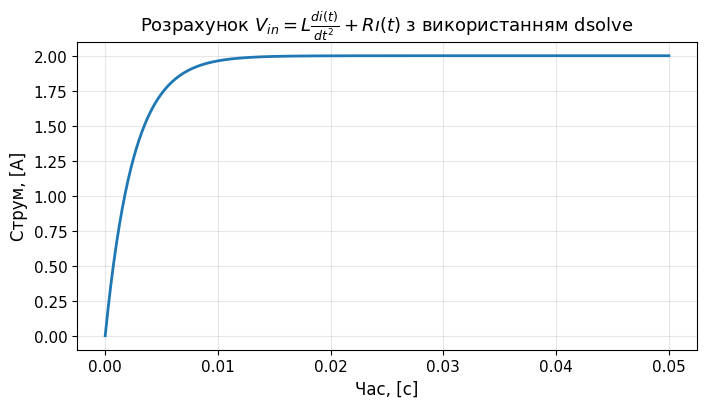

In [8]:
# Крок 1: параметри кола
R = 40  # опір, Ом
L = 0.1  # індуктивність, Гн
# C = 0.05  # ємність, Ф
V = 80   # постійна напруга джерела, В

t = smp.symbols('t')  # час
I = smp.Function('I')(t)  # струм у колі i(t)

# Крок 2: диференціальне рівняння
eq = L * I.diff(t, 1) + R * I - V
# Початкова умова: i(0) = 0 (перший закон комутації)
ics = {I.subs(t, 0): 0}

# Крок 3: розв'язуємо диференціальне рівняння
sol = smp.dsolve(eq, I, ics=ics)

# Крок 4: перетворюємо символьний розв'язок на функцію Python
I_func = smp.lambdify(t, sol.rhs, 'numpy')

# Крок 5: моменти часу
time_values = np.linspace(0, 0.05, 1000)  # інтервал часу, с

# Крок 6: i(t) у кожен момент часу
current_values = np.array([I_func(ti) for ti in time_values])

# Крок 7: графік
plt.plot(time_values, current_values)
plt.title('Розрахунок $ V_{in} = L\\frac{di(t)}{dt^{2}} + R\\i(t) $ з використанням dsolve')
plt.xlabel('Час, [c]')
plt.ylabel('Струм, [A]')
plt.grid(True)
plt.show()

#### 📌 Підсумок: Перехідний процес RL ланцюга

<div style="background-color: #f0fdf4; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Закон комутації для індуктивності (перший закон):**
$$i_L(0_-) = i_L(0_+)$$
Струм через котушку індуктивності не може змінитися стрибком.

**Струм при підключенні RL до джерела напруги $V$:**
$$i(t) = \frac{V}{R}\left(1 - e^{-\frac{R}{L}t}\right) = \frac{V}{R}\left(1 - e^{-t/\tau}\right)$$

**Постійна часу:** $\tau = \dfrac{L}{R}$ (секунди)

**Напруга на індуктивності:** $u_L(t) = V \cdot e^{-t/\tau}$

</div>



---
#### ⚡ Практичне застосування: Перехідний процес RL ланцюга

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**RL-ланцюги у радіотехніці:**

| Застосування | tau типове | Пояснення |
|-------------|-----------|----------|
| **Фільтр НЧ (дросель + навантаження)** | 10–100 мкс | Придушення ВЧ-завад у блоках живлення |
| **Котушка реле** | 1–10 мс | Перехідний процес при ввімкненні/вимкненні реле |
| **Розмагнічування трансформатора** | мс | Захист від перенапруг при відключенні |
| **ВЧ-дросель у підсилювачі** | нс–мкс | Ізоляція ВЧ-тракту від кіл живлення |

> **Зворотний ЕРС:** При розмиканні кола з котушкою виникає ЕРС самоіндукції
> $e_L = -L \cdot di/dt$, яка може у десятки разів перевищувати напругу живлення.
> Захист — діод шунтування (flyback diode).

</div>

---
#### ✅ Питання для самоперевірки: Перехідний процес RL ланцюга

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Що фізично означає постійна часу tau = L/R?</summary>

> **Відповідь:** Час, за який струм змінюється на 63.2% від кінцевого значення. Це характеристичний час накопичення/розсіювання магнітної енергії в котушці.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чому струм через котушку не може змінитися стрибком?</summary>

> **Відповідь:** Миттєва зміна струму $\Delta i$ потребувала б нескінченно великої напруги $u_L = L \cdot di/dt \to \infty$, що неможливо для реального джерела з кінцевою потужністю.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> За скільки постійних часу перехідний процес вважається завершеним і чому?</summary>

> **Відповідь:** Практично за $5\tau$: $e^{-5} \approx 0.0067$, тобто залишок відхилення — менш ніж 1% від кінцевого значення.

</details>

---
#### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Не переплутайте формули постійної часу! Для **RL** кола (щойно розглянутого вище): $\tau = L/R$. Для **RC** кола, яке починається нижче: $\tau = R \cdot C$. Легко перевірити розмірністю: $[L/R] = \text{Гн}/\text{Ом} = \text{с}$, $[RC] = \text{Ом}\cdot\text{Ф} = \text{с}$ — обидві дають секунди, тому формули не можна впізнати «на око», якщо не пам'ятати, яка з них до якого кола відноситься.


</div>


---

### Розрахунок перехідного процесу RC ланцюга  <a class="anchor" id="RC-commutation-calculation-classic"></a>

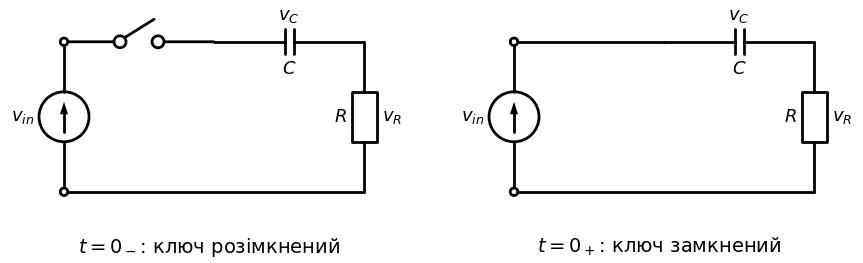

In [9]:
# Схема: RC-коло до і після комутації (функцію switching_pair визначено вище)
if SCHEMDRAW_AVAILABLE:
    switching_pair(elm.Capacitor, '$v_C$', '$C$')

Запишемо рівняння яке описує схему:

$$
  v_{in}(t) = v_{c}(t) + R C \frac{d u_{C}(t)}{dt};
$$

Розв’язок диференційного рівняння складає вільну та вимушену складові і отримуємо

$$
v_{c}(t) = v_{вм}(t) + v_{вл}(t)
$$

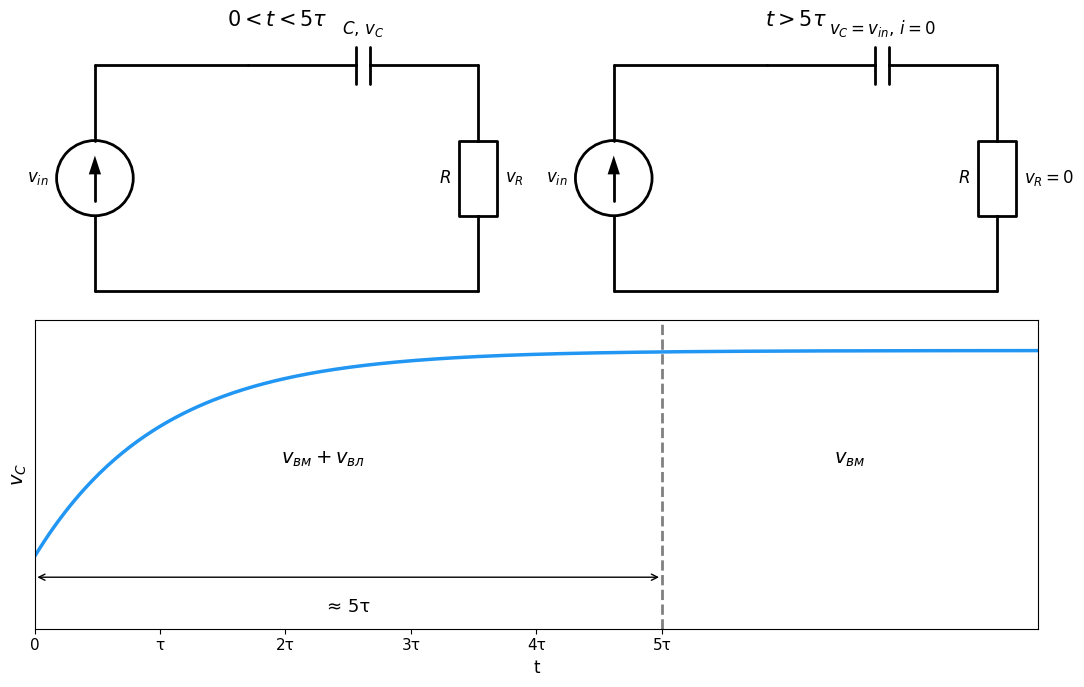

In [10]:
# Схема і графік: напруга на конденсаторі RC-кола у перехідному та усталеному режимах
if SCHEMDRAW_AVAILABLE:
    transient_phases(elm.Capacitor, '$C$, $v_C$', '$v_C = v_{in}$, $i = 0$', '$v_C$',
                     '$v_{вм} + v_{вл}$', '$v_{вм}$', rc=True)

---

Виконаємо розрахунок для наступних параметрів схеми:

$$v_{in} = 80 [V] \quad R=40 [\Omega] \quad C = 0.1 [mF] $$

---

Вимушена складова має вигляд

Оскільки $\omega = 2 \pi f$, а частота постійного джерела напруги нульова:

$$v_{вм}(t) = v_{in}(t) = 80 V$$

Конденсатор зарядиться до напруги живлення. В цей момент відповідно струм буде 0 і падіння напруги на резисторі також буди 0.

Вільна складова має вигляд:

$$v_{вл}(t) = A e^{pt}$$

Запишемо характеристичне рівняння:

$$
  Z(j \omega) = R + \cfrac{1}{j \omega C};
$$

Виконаємо заміну на p і приведемо до загального знаменника:

$$
  Z(p) = R + \cfrac{1}{pC} = \cfrac{RpC+1}{pC};
$$

Прирівняємо праву частину до 0:

$$
  \cfrac{RpC+1}{pC} = 0;
$$

Дріб буде нульовий коли чисельник буде рівним нулю, тоді:

$$
  RpC+1 = 0;
$$

Тоді р:

$$
  p = \cfrac{-1}{RC} = -\frac{1}{4*10^{-3}} = -250;
$$

Для знаходження $A$ підставляємо отримані значення до $v_{c}(t)$:

$$
v_{c}(t) = v_{вм}(t) + v_{вл}(t) = 80V + A e^{-250}
$$

В момент $t(0+)$, враховуючи перший закон комутації:

$$
v_{c}(0+) = v_{вм}(t) + v_{вл}(t) = 80V + A e^{-250 \cdot 0} = 40 + A;
$$

$$
A = -80;
$$

Розв'язок:
$$
v_{c}(t) = 80 - 80 e^{-250 \cdot t} [V];
$$

In [11]:
# Інтерактивний перехідний процес RC ланцюга
def rc_transient(R_sb=40, C_sb=1.0, V_sb=10, mode='Заряд (підключення до V)'):
    C_F = C_sb * 1e-3  # мФ -> Ф
    tau = R_sb * C_F
    t_max = 5 * tau
    t_vals = np.linspace(0, t_max, 500)
    if mode == 'Заряд (підключення до V)':
        uC_vals = V_sb * (1 - np.exp(-t_vals / tau))
        i_vals = (V_sb / R_sb) * np.exp(-t_vals / tau)
        title = 'Заряд: u_C(t) = V(1 - e^{-t/tau})'
    else:
        uC_vals = V_sb * np.exp(-t_vals / tau)
        i_vals = -(V_sb / R_sb) * np.exp(-t_vals / tau)
        title = 'Розряд: u_C(t) = V * e^{-t/tau}'

    uR_vals = i_vals * R_sb
    W_C = 0.5 * C_F * uC_vals**2

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(t_vals*1000, uC_vals, '#2196F3', label='u_C(t)')
    axes[0].axvline(tau*1000, color='red', ls='--', label=f'tau={tau*1000:.1f} мс')
    axes[0].axhline(0.632*V_sb, color='orange', ls=':', label='0.632 V')
    axes[0].set_xlabel('Час, мс'); axes[0].set_ylabel('Напруга, В')
    axes[0].set_title(title); axes[0].legend()

    axes[1].plot(t_vals*1000, i_vals*1000, '#4CAF50')
    axes[1].set_xlabel('Час, мс'); axes[1].set_ylabel('Струм, мА')
    axes[1].set_title('Струм i(t) = (V/R)e^{-t/tau}')

    axes[2].plot(t_vals*1000, W_C*1e6, '#FF9800')
    axes[2].set_xlabel('Час, мс'); axes[2].set_ylabel('Енергія, мкДж')
    axes[2].set_title(f'Енергія W_C = 0.5C*u_C^2\nW_max = {0.5*C_F*V_sb**2*1e6:.2f} мкДж')

    plt.suptitle(f'RC ланцюг: R={R_sb} Ом, C={C_sb} мФ, V={V_sb} В | tau={tau*1000:.2f} мс',
                 fontsize=11)
    plt.tight_layout(); plt.show()
    print(f'tau = RC = {tau:.4f} с = {tau*1000:.2f} мс')
    print(f'U_C_уст = {V_sb:.2f} В | W_C_max = {0.5*C_F*V_sb**2*1e6:.4f} мкДж')

interact(rc_transient,
         R_sb=widgets.IntSlider(min=10, max=1000, step=10, value=40, description='R (Ом)'),
         C_sb=widgets.FloatSlider(min=0.01, max=10, step=0.1, value=1.0, description='C (мФ)'),
         V_sb=widgets.FloatSlider(min=1, max=100, step=1, value=10, description='V (В)'),
         mode=widgets.Dropdown(options=['Заряд (підключення до V)', 'Розряд (відключення)'],
                               description='Режим'))

interactive(children=(IntSlider(value=40, description='R (Ом)', max=1000, min=10, step=10), FloatSlider(value=…

<function __main__.rc_transient(R_sb=40, C_sb=1.0, V_sb=10, mode='Заряд (підключення до V)')>

Аналітичний розрахунок: SymPy (`dsolve`) розв'язує рівняння $RC\,\dfrac{dv_C}{dt} + v_C = v_{in}$ з початковою умовою $v_C(0) = 0$; будуємо графік $v_C(t)$.

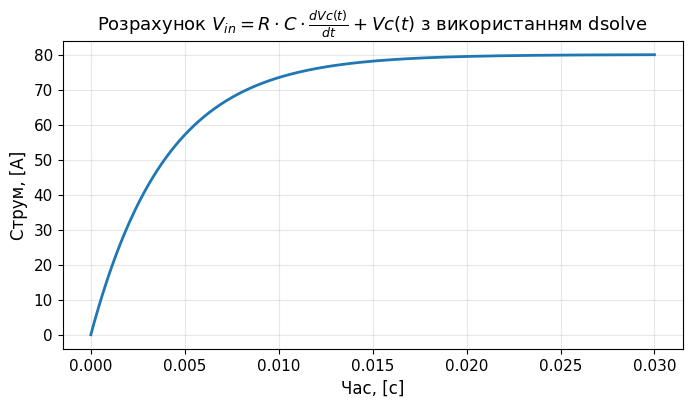

In [12]:
# Крок 1: параметри кола
R = 40  # опір, Ом
# L = 0.1  # індуктивність, Гн
C = 0.1*1e-3  # ємність, Ф
V = 80   # постійна напруга джерела, В

t = smp.symbols('t')  # час
Vc = smp.Function('Vc')(t)  # напруга на конденсаторі v_C(t)


# Крок 2: диференціальне рівняння
eq = R * C * Vc.diff(t) + Vc - V
# Початкова умова: v_C(0) = 0 (другий закон комутації)
ics = {Vc.subs(t, 0): 0}

# Крок 3: розв'язуємо диференціальне рівняння
sol = smp.dsolve(eq, Vc, ics=ics)

# Крок 4: перетворюємо символьний розв'язок на функцію Python
Vc_func = smp.lambdify(t, sol.rhs, 'numpy')

# Крок 5: моменти часу
time_values = np.linspace(0, 0.03, 1000)  # інтервал часу, с

# Крок 6: v_C(t) у кожен момент часу
current_values = np.array([Vc_func(ti) for ti in time_values])

# Крок 7: графік
plt.plot(time_values, current_values)
plt.title(r'Розрахунок $ V_{in} =  R\cdot C \cdot\frac{dVc(t)}{dt} + Vc(t) $ з використанням dsolve')
plt.xlabel('Час, [c]')
plt.ylabel('Струм, [A]')
plt.grid(True)
plt.show()

#### 📌 Підсумок: Перехідний процес RC ланцюга

<div style="background-color: #f0fdf4; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Закон комутації для ємності (другий закон):**
$$u_C(0_-) = u_C(0_+)$$
Напруга на конденсаторі не може змінитися стрибком.

**Напруга при заряді RC ланцюга від джерела $V$:**
$$u_C(t) = V\left(1 - e^{-\frac{t}{RC}}\right) = V\left(1 - e^{-t/\tau}\right)$$

**Постійна часу:** $\tau = R \cdot C$ (секунди)

**Струм у ланцюзі:** $i(t) = \dfrac{V}{R} e^{-t/\tau}$

</div>

---


---
#### ⚡ Практичне застосування: Перехідний процес RC ланцюга

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**RC-ланцюги у радіотехніці:**

| Застосування | tau типове | Пояснення |
|-------------|-----------|----------|
| **Фільтр НЧ (інтегруюче коло)** | залежно від смуги | Згладжування пульсацій, детектор АМ |
| **Диференціюче коло** | << T сигналу | Виділення фронтів прямокутного імпульсу |
| **Тайм-схема (555 таймер)** | мкс–хвилини | RC визначає час спрацювання |
| **Схема сполучення каскадів** | RC >> 1/f_min | Блокування DC, пропускання AC |
| **АЦП Sample-and-Hold** | нс | Час вибірки аналогового сигналу |

> **Частота зрізу:** $f_c = \frac{1}{2\pi RC} = \frac{1}{2\pi \tau}$.
> При $f = f_c$ рівень АЧХ = $-3$ дБ (у $\sqrt{2}$ разів менший за максимальний).

</div>

---
#### ✅ Питання для самоперевірки: Перехідний процес RC ланцюга

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому напруга на конденсаторі не може змінитися стрибком?</summary>

> **Відповідь:** Миттєва зміна $\Delta U_C$ потребувала б нескінченно великого струму $i = C \cdot dU_C/dt \to \infty$, що неможливо для реального кола з кінцевим опором.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чим відрізняється інтегруюче коло від диференціюючого?</summary>

> **Відповідь:** Інтегруюче RC ($\tau \gg T$): вихідний сигнал — з ємності, форма наближена до інтеграла вхідного. Диференціюче RC ($\tau \ll T$): вихідний сигнал — з резистора, форма наближена до похідної вхідного.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Яка енергія накопичується в конденсаторі при зарядці до напруги V?</summary>

> **Відповідь:** $W_C = \frac{1}{2}CV^2$. При цьому рівно така ж енергія розсіюється на резисторі $R$, незалежно від його величини. Тобто ККД заряду ємності від джерела напруги через резистор — 50%.

</details>

---
### 📝 Задачі для самостійного розв'язання: Перехідні процеси в RL та RC ланцюгах


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Котушка $L = 0{,}1$ Гн з опором $R = 10$ Ом вмикається на постійну напругу $E = 20$ В. Знайдіть $\tau$, усталений струм, $i(10\text{ мс})$, напругу на котушці в момент $t = 0_+$ та час, за який перехідний процес практично завершиться.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $\tau = L/R = 10$ мс; $I_{уст} = 2$ А; $i(t) = 2(1 - e^{-100t})$, $i(10\text{ мс}) \approx 1{,}26$ А; $u_L(0_+) = E = 20$ В (струм котушки не стрибає, тому вся напруга — на $L$); $t \approx (3\ldots5)\tau = 30\ldots50$ мс.

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Конденсатор $C = 10$ мкФ заряджається через $R = 10$ кОм від $E = 50$ В ($u_C(0) = 0$). Знайдіть $\tau$, $i(0_+)$, $u_C(0{,}2\text{ с})$ і енергію, розсіяну в резисторі за весь процес заряду.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $\tau = RC = 0{,}1$ с; $i(0_+) = E/R = 5$ мА; $u_C(0{,}2) = 50(1 - e^{-2}) \approx 43{,}2$ В. Енергія в конденсаторі $W_C = CE^2/2 = 12{,}5$ мДж; стільки ж ($12{,}5$ мДж) розсіюється в резисторі **незалежно від $R$**.

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 3.** У котушці $L = 0{,}1$ Гн ($R = 10$ Ом) усталився струм 2 А. Джерело відключають, і котушка замикається на розрядний резистор $R_р = 100$ Ом. Яка напруга виникне на $R_р$ у момент комутації? Яка стала часу розряду?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> За першим законом комутації $i(0_+) = i(0_-) = 2$ А, тож $u_{Rр}(0_+) = 2\cdot100 = 200$ В — у 10 разів більше за напругу джерела (20 В)! $\tau = L/(R + R_р) \approx 0{,}91$ мс. Ось чому котушки реле шунтують діодом.

</details>

---

## Вмикання кіл на синусоїдальну напругу <a class="anchor" id="ac-switching"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Записувати вимушену складову перехідного процесу при синусоїдному джерелі
> - Пояснювати, чому вигляд вільної складової (τ, характеристичне рівняння) не залежить від типу джерела
> - Визначати, за якої фази включення транзиторний струм максимальний, а за якої — відсутній

</div>

### RL-коло, яке вмикається на синусоїдну напругу

Нехай до кола $R,L$ (спочатку знеструмленого, $i(0_-)=0$) у момент $t=0$ підключають джерело $v_{in}(t)=V_m\sin(\omega t+\psi)$, де $\psi$ — **фаза включення** (значення фази синусоїди саме в момент комутації).

Диференціальне рівняння кола таке саме, як і для постійної напруги — джерело живлення входить лише через праву частину:

$$L\frac{di}{dt}+Ri = V_m\sin(\omega t+\psi)$$

**Вільна складова** визначається тим самим характеристичним рівнянням $R+pL=0$, що й при вмиканні на постійну напругу (воно залежить лише від топології кола, а не від джерела):

$$i_{вл}(t) = A\,e^{-t/\tau}, \qquad \tau=\frac{L}{R}$$

**Вимушена складова** — це усталений синусоїдний режим, який шукають символічним методом:

$$i_{вим}(t) = I_m\sin(\omega t+\psi-\varphi), \qquad I_m=\frac{V_m}{\sqrt{R^2+(\omega L)^2}}, \qquad \varphi=\operatorname{arctg}\frac{\omega L}{R}$$

**Стала інтегрування** знаходиться з початкової умови $i(0_+)=i(0_-)=0$:

$$0 = I_m\sin(\psi-\varphi) + A \quad\Longrightarrow\quad A=-I_m\sin(\psi-\varphi)$$

$$\boxed{i(t) = I_m\sin(\omega t+\psi-\varphi) - I_m\sin(\psi-\varphi)\,e^{-t/\tau}}$$

### Вплив фази включення

- Якщо **$\psi-\varphi=0$ або $\pi$** («включення у фазі»), то $\sin(\psi-\varphi)=0$, стала $A=0$ — вільна складова відсутня, і коло одразу переходить в усталений синусоїдний режим без перехідного процесу.
- Якщо **$\psi-\varphi=\pm\pi/2$** («включення в квадратурі»), $\sin(\psi-\varphi)=\pm1$ — стала максимальна за модулем, $A=\mp I_m$, і струм у перший момент після комутації може сягати майже подвоєної амплітуди усталеного струму $I_m$ — це **найгірший (найбільш небезпечний) випадок включення**, який враховують при виборі комутаційної апаратури (вимикачів, запобіжників) для потужних індуктивних навантажень (трансформатори, електродвигуни).


Змоделюємо вмикання RL-кола на синусоїдну напругу при різних фазах вмикання $\psi$ і порівняємо кидок струму:

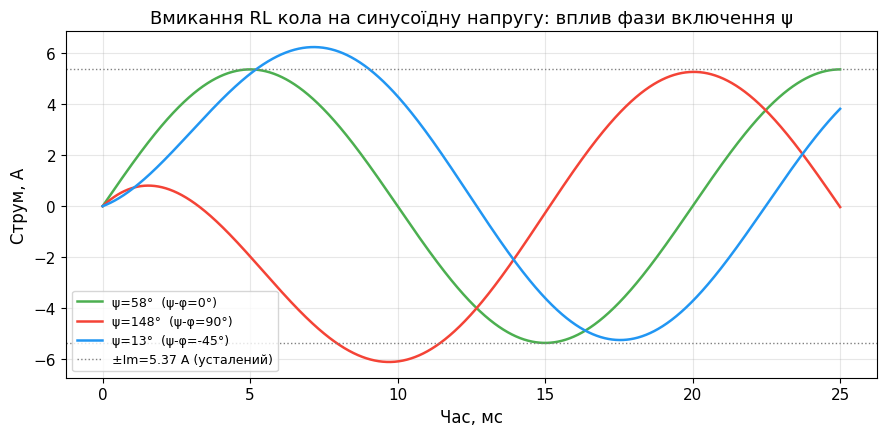

tau = 5.00 мс, Im = 5.370 А, φ = 57.5°
При ψ-φ=0 перехідного процесу немає; при ψ-φ=±90° кидок струму максимальний (до ~2·Im).


In [13]:
# Вплив фази включення на кидок струму при вмиканні RL кола на синусоїдну напругу
R_ac, L_ac, Vm_ac, f_ac = 10.0, 0.05, 100.0, 50.0
w_ac = 2*np.pi*f_ac
tau_ac = L_ac / R_ac
Im_ac = Vm_ac / np.sqrt(R_ac**2 + (w_ac*L_ac)**2)
phi_ac = np.arctan2(w_ac*L_ac, R_ac)

t_ac = np.linspace(0, 5*tau_ac, 2000)

fig, ax = plt.subplots(figsize=(9, 4.5))
for psi_deg, color in [(np.degrees(phi_ac), '#4CAF50'), (np.degrees(phi_ac)+90, '#F44336'), (np.degrees(phi_ac)-45, '#2196F3')]:
    psi = np.radians(psi_deg)
    i_t = Im_ac*np.sin(w_ac*t_ac+psi-phi_ac) - Im_ac*np.sin(psi-phi_ac)*np.exp(-t_ac/tau_ac)
    ax.plot(t_ac*1e3, i_t, color=color, lw=1.8, label=f'ψ={psi_deg:.0f}°  (ψ-φ={psi_deg-np.degrees(phi_ac):.0f}°)')

ax.axhline(Im_ac, color='gray', ls=':', lw=1)
ax.axhline(-Im_ac, color='gray', ls=':', lw=1, label=f'±Im={Im_ac:.2f} А (усталений)')
ax.set_xlabel('Час, мс'); ax.set_ylabel('Струм, А')
ax.set_title('Вмикання RL кола на синусоїдну напругу: вплив фази включення ψ')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print(f'tau = {tau_ac*1000:.2f} мс, Im = {Im_ac:.3f} А, φ = {np.degrees(phi_ac):.1f}°')
print('При ψ-φ=0 перехідного процесу немає; при ψ-φ=±90° кидок струму максимальний (до ~2·Im).')


---
### ⚡ Практичне застосування: Вмикання на синусоїдну напругу

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

- **Пусковий кидок струму трансформатора (inrush current)** — якщо трансформатор вмикають у мережу саме в момент, близький до найгіршої фази ($\psi-\varphi\approx\pm90°$), намагнічувальний струм може у кілька разів перевищувати номінальний, що враховують при виборі запобіжників і автоматів.
- **М'який пуск (soft-start) потужних електродвигунів** — керовані тиристорні пускачі свідомо підбирають момент включення (кут керування), щоб уникнути «найгіршої фази» і зменшити пусковий струм.
- **Комутаційні перенапруги в енергетиці** — аналогічний ефект для RLC-кіл (лінії, компенсаційні конденсаторні батареї) враховують при проєктуванні вимикачів високої напруги.

</div>

---
### ✅ Питання для самоперевірки: Вмикання на синусоїдну напругу

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому стала часу τ=L/R однакова, чи вмикається коло на постійну, чи на синусоїдну напругу?</summary>

> **Відповідь:** Стала часу визначається коренем характеристичного рівняння $R+pL=0$, яке залежить лише від параметрів самого кола (R, L) і не залежить від виду джерела — форма вільної складової $e^{-t/\tau}$ та сама, змінюється лише спосіб знаходження сталої A через вимушену складову.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> За якої умови включення RL кола на синусоїдну напругу перехідний процес не виникає взагалі?</summary>

> **Відповідь:** Коли фаза включення співпадає з фазою вимушеної складової в момент комутації ($\psi-\varphi=0$ або $\pi$), тобто $i_{вим}(0_+)=i(0_-)=0$ автоматично — стала A=0 і коло одразу в усталеному режимі.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому найбільший кидок струму небезпечний саме для індуктивних навантажень (трансформаторів, двигунів)?</summary>

> **Відповідь:** У найгіршому випадку ($\psi-\varphi=\pm90°$) миттєвий струм може досягати майже подвоєної амплітуди усталеного режиму — для потужних індуктивних навантажень це означає значний струмовий кидок, здатний спрацювати захист або пошкодити обмотки, тому це явище обов'язково враховують при проєктуванні пускової апаратури.

</details>

---
### 📝 Задачі для самостійного розв'язання: Вмикання на синусоїдну напругу


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Коло $R = 2$ Ом, $L = 63{,}7$ мГн ($X_L = 20$ Ом на 50 Гц) вмикається на напругу $u = 201\sin(\omega t + \psi)$ В. Знайдіть амплітуду усталеного струму, фазу вмикання $\psi$, за якої перехідного процесу немає, і оцініть найбільший кидок струму.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $Z = \sqrt{2^2 + 20^2} \approx 20{,}1$ Ом, $\varphi = \arctan(20/2) \approx 84{,}3°$, $I_m = 10$ А. Вільна складова $i_{св}(0) = -I_m\sin(\psi - \varphi)$ дорівнює нулю при $\psi = \varphi \approx 84{,}3°$. Найгірший випадок — $\psi - \varphi = \pm90°$ (вмикання поблизу переходу напруги через нуль): через півперіоду струм сягає $\approx 17{,}3$ А $\approx 1{,}73I_m$ (при $\tau = L/R \approx 32$ мс $> T/2 = 10$ мс, кидок наближається до $2I_m$).

</details>

---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Бойко В. С., Бойко В. В., Видолоб Ю. Ф. та ін. Теоретичні основи електротехніки: підручник. Т. 1. Усталені режими лінійних електричних кіл із зосередженими параметрами. — К.: ІВЦ «Видавництво «Політехніка», 2004.
2. Гоноровский И. С. Радиотехнические цепи и сигналы. — М.: Радио и связь, 1986.
3. Баскаков С. И. Радиотехнические цепи и сигналы. — М.: Высшая школа, 2000.
4. Alexander C. K., Sadiku M. N. O. Fundamentals of Electric Circuits. — McGraw-Hill.

**Додаткова література**

5. Oppenheim A. V., Willsky A. S. Signals and Systems. — 2nd ed. — Prentice Hall, 1997.
6. Lathi B. P., Ding Z. Modern Digital and Analog Communication Systems. — Oxford University Press.
7. Pozar D. M. Microwave Engineering. — 4th ed. — Wiley, 2012 *(розділ про лінії передачі)*.

**Програмні інструменти, що використовуються в конспекті**

- [SymPy](https://docs.sympy.org/) — символьні обчислення (розв'язання систем рівнянь, перетворення Лапласа)
- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки

---

<p style="text-align: center;">⬅️ [Тема 9. Трифазні кола](Тема_09_Трифазні_кола.ipynb) &nbsp;|&nbsp; [Тема 11. Операторний метод розрахунку перехідних процесів](Тема_11_Операторний_метод.ipynb) ➡️</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*
